In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, OrdinalEncoder
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score

# Load Dataset

The dataset contains approximately 7.7 million accident records collected in the United States. The goal of this project is to build a predictive model able to predict the severity of an accident given geographical, weather, and other contextual information.


In [100]:
df = pd.read_parquet("US_accidents_dataset.parquet")
df = df.drop(columns = ["ID"])
len(df)

7728394

# Analysis
This section contains Exploratory Data Analysis (EDA). The purpose is to analyze the data, looking at missing values, correlations between covariates and with the target, with the aim of understanding meaningful predictors, data leakage, and messy data, such as outliers or missing values.

## severity distribution
First, we look at the distribution of severity values to understand if the dataset is balanced. Clearly, from the histograms it is notable that the dataset is not balanced; moreover, accidents with severity 4, which are the most important to predict in the context of this project, are underrepresented.

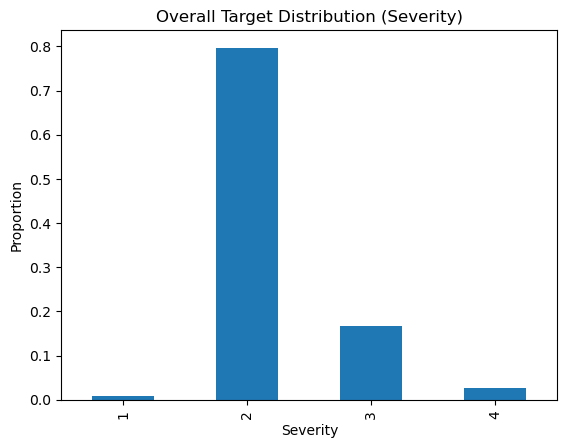

In [3]:
plt.figure()
df["Severity"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Overall Target Distribution (Severity)")
plt.xlabel("Severity")
plt.ylabel("Proportion")
plt.show()

## missing values
In this subsection, we look for missing values. We count the occurrence and percentage of missing values per column. Later, we look at the histograms, for each column, of severity values for samples with and without missing values in that column. The purpose is to understand if the missing values are correlated with the target. This is important to decide how to treat missing values later, since if the values are not completely missing at random, they cannot simply be eliminated by deleting the corresponding rows.

### count

In [4]:
df = df.replace(["", "NA", "null", "None", None], np.nan)

missing_count = df.isna().sum()
missing_pct = df.isna().mean() * 100

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_pct": missing_pct
})

missing_summary

,missing_count,missing_pct
Source,0,0.000000
Severity,0,0.000000
Start_Time,0,0.000000
End_Time,0,0.000000
Start_Lat,0,0.000000
Start_Lng,0,0.000000
End_Lat,3402762,44.029355
End_Lng,3402762,44.029355
Distance(mi),0,0.000000
Description,5,0.000065


### vs traget distributions

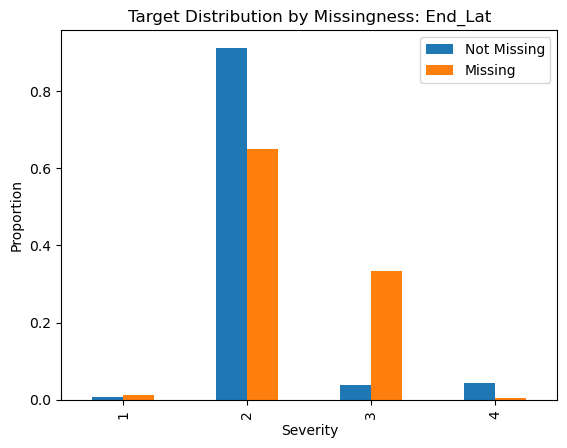

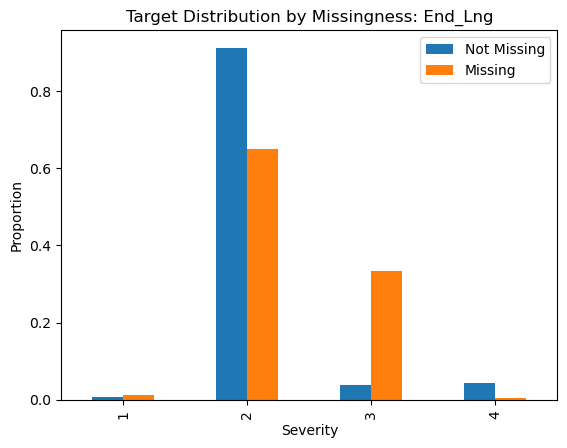

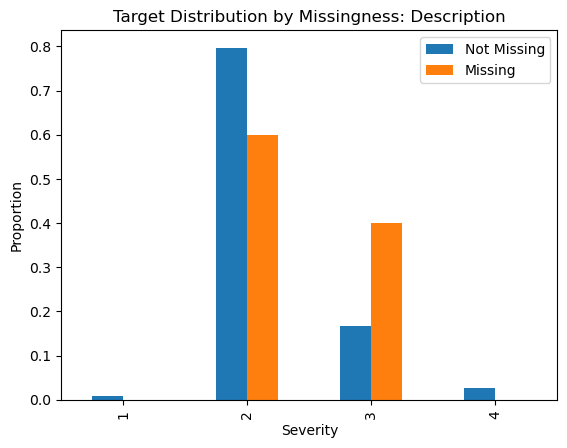

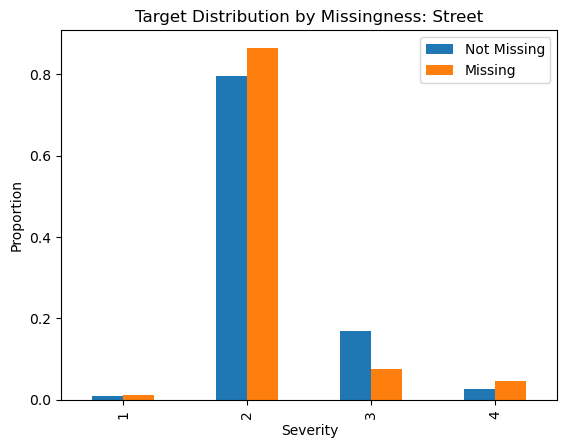

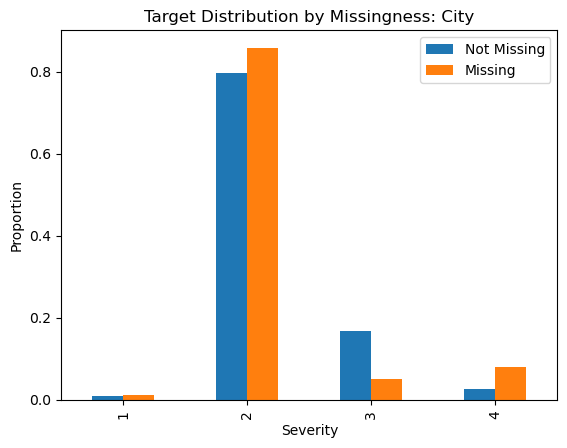

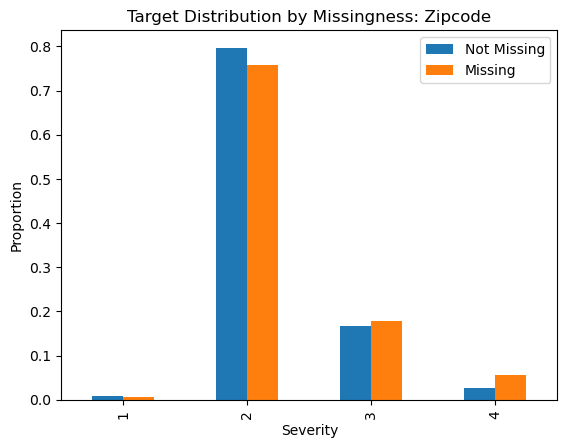

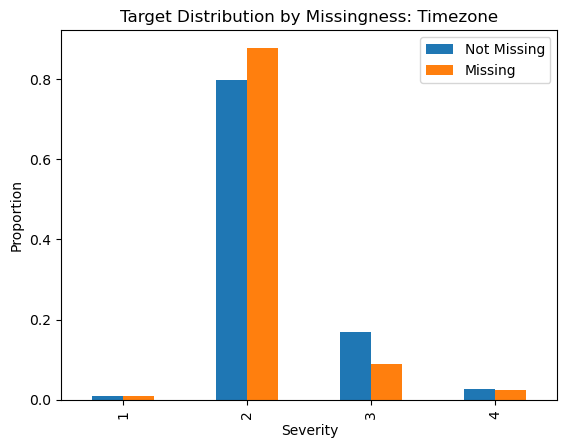

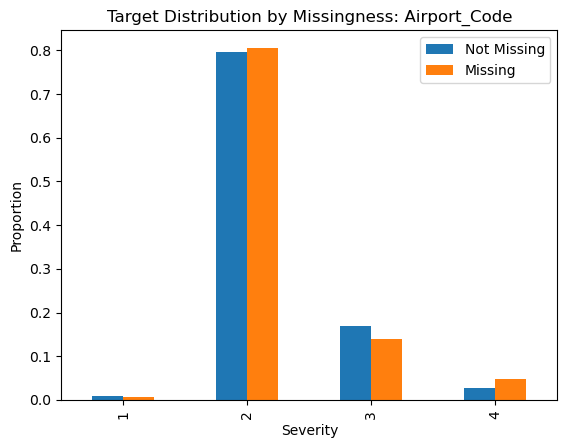

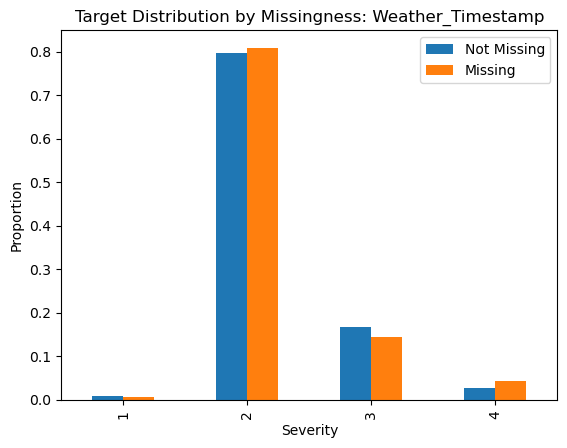

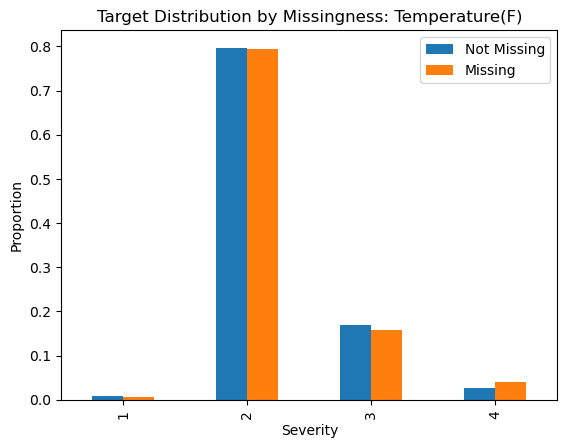

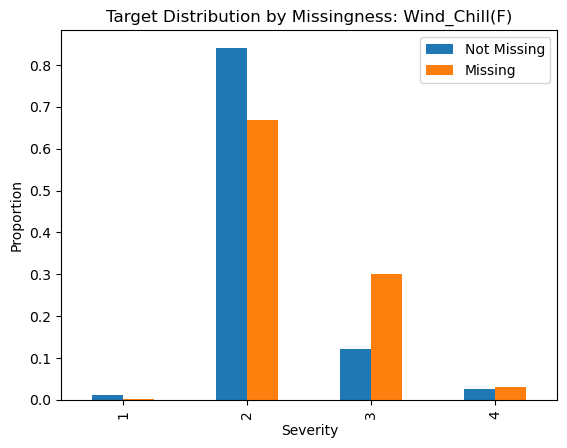

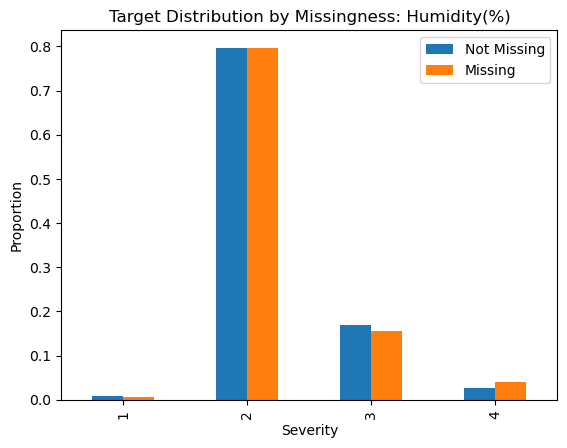

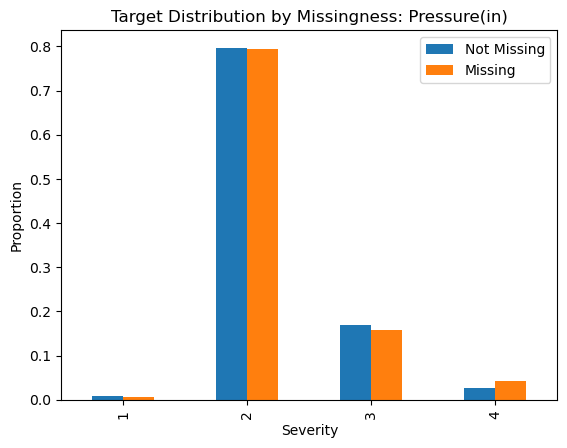

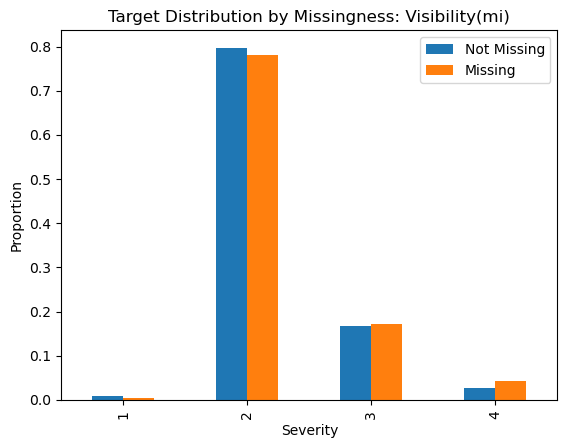

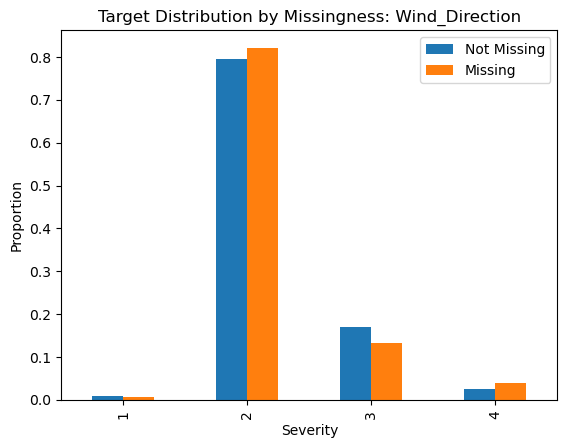

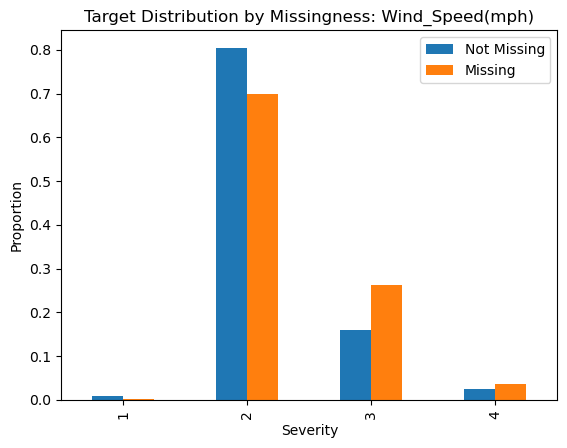

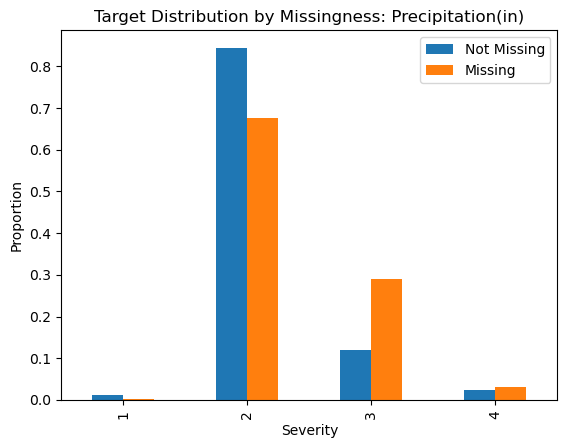

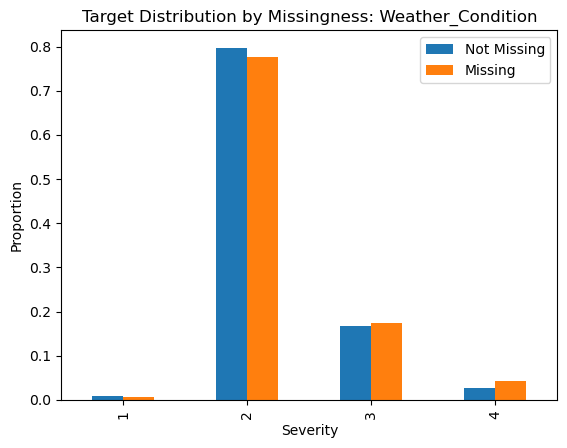

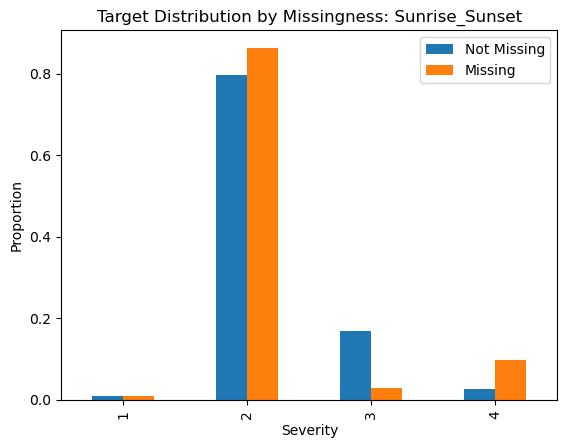

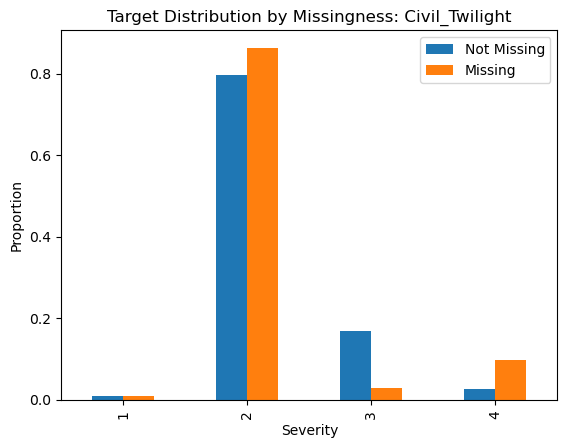

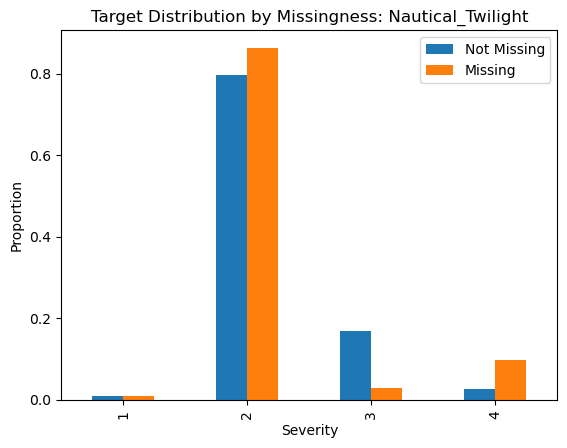

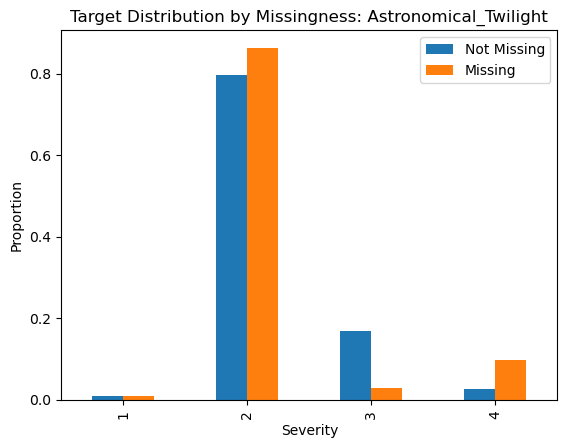

In [5]:
for col in df.columns:
    if col != "Severity":
        temp = df[col].isna().astype(int)
        if temp.nunique() > 1 :
        
            # Crosstab normalized (same as before)
            ct = pd.crosstab(temp, df["Severity"], normalize="index")
            
            # Plot
            ct.T.plot(kind="bar")  # transpose for nicer layout
            
            plt.title(f"Target Distribution by Missingness: {col}")
            plt.xlabel("Severity")
            plt.ylabel("Proportion")
            plt.legend(["Not Missing", "Missing"])
            plt.show()

### correlation
Here we look for correlations between missing values. For example, from the correlation matrix we can see that all the samples with missing values in the column Sunrise_Sunset also have missing values in Civil_Twilight, Nautical_Twilight, and Astronomical_Twilight.

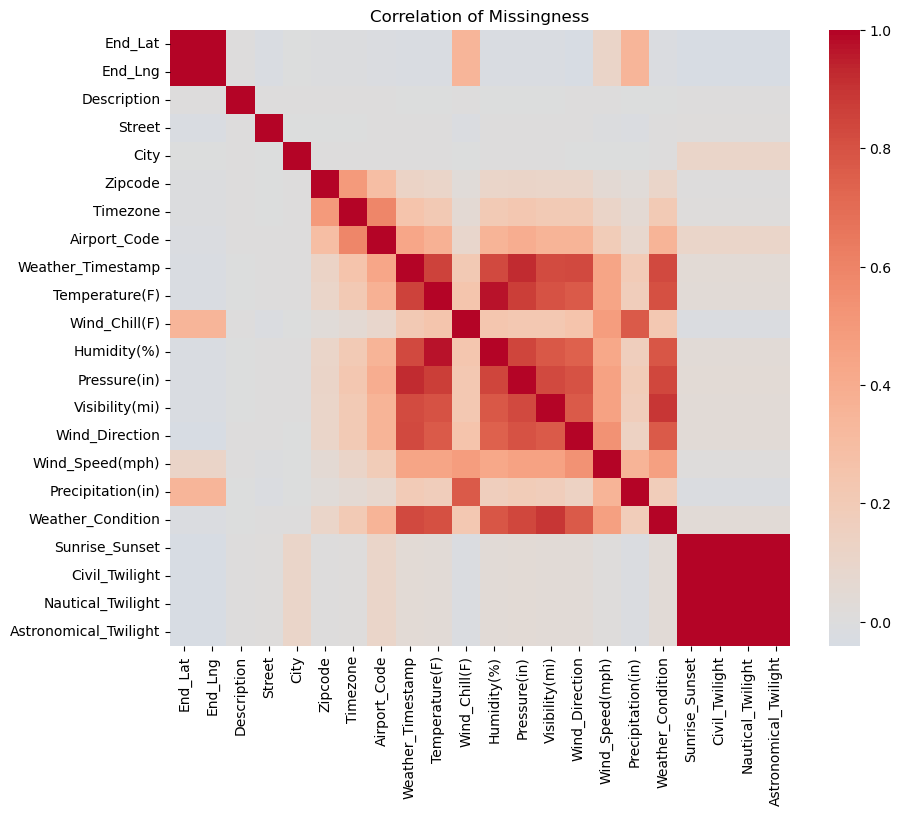

In [6]:
missing = df.isna().astype(int)
missing = missing.loc[:, missing.nunique() > 1]
missing_corr = missing.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(missing.corr(), cmap="coolwarm", center=0)
plt.title("Correlation of Missingness")
plt.show()

##  numerical features
In this subsection, we analyze numerical variables. We first compute the variance of each column to identify variables that may be constant and therefore not useful for prediction. In this case, no such variables are found; however, the analysis highlights that the numerical features have different scales and therefore require normalization.

Next, we examine correlations between numerical variables. Highly correlated features may be redundant, and one of them can potentially be removed. This is particularly relevant for models that are sensitive to multicollinearity.

Finally, we analyze boxplots of the numerical variables with respect to severity. This allows us to identify potential shifts in distributions for high-severity accidents and to detect the presence of outliers.


In [7]:
num_vars = ["Start_Lat", "End_Lat", "Start_Lng", "End_Lng", "Distance(mi)", "Temperature(F)", "Wind_Chill(F)","Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
df[num_vars].head()


,Start_Lat,End_Lat,Start_Lng,End_Lng,Distance(mi),Temperature(F),Wind_Chill(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph),Precipitation(in)
0,39.865147,NaN,-84.058723,NaN,0.01,36.9,NaN,91.0,29.68,10.0,NaN,0.02
1,39.928059,NaN,-82.831184,NaN,0.01,37.9,NaN,100.0,29.65,10.0,NaN,0.00
2,39.063148,NaN,-84.032608,NaN,0.01,36.0,33.3,100.0,29.67,10.0,3.5,NaN
3,39.747753,NaN,-84.205582,NaN,0.01,35.1,31.0,96.0,29.64,9.0,4.6,NaN
4,39.627781,NaN,-84.188354,NaN,0.01,36.0,33.3,89.0,29.65,6.0,3.5,NaN


In [ ]:
# Convert latitude and longitude columns (End_Lat, End_Lng) from string to float
df["End_Lat"] = df["End_Lat"].apply(pd.to_numeric, errors="coerce")
df["End_Lng"] = df["End_Lng"].apply(pd.to_numeric, errors="coerce")
df[num_vars].dtypes

Start_Lat            float64
End_Lat              float64
Start_Lng            float64
End_Lng              float64
Distance(mi)         float64
Temperature(F)       float64
Wind_Chill(F)        float64
Humidity(%)          float64
Pressure(in)         float64
Visibility(mi)       float64
Wind_Speed(mph)      float64
Precipitation(in)    float64
dtype: object

### variance

In [9]:
var = df[num_vars].var().sort_values()
var

Precipitation(in)      0.012149
Pressure(in)           1.012418
Distance(mi)           3.157056
Visibility(mi)         7.227042
Start_Lat             25.766579
End_Lat               27.803522
Wind_Speed(mph)       29.430445
Start_Lng            302.473186
End_Lng              327.897043
Temperature(F)       361.519011
Wind_Chill(F)        501.304566
Humidity(%)          520.796565
dtype: float64

### correlation

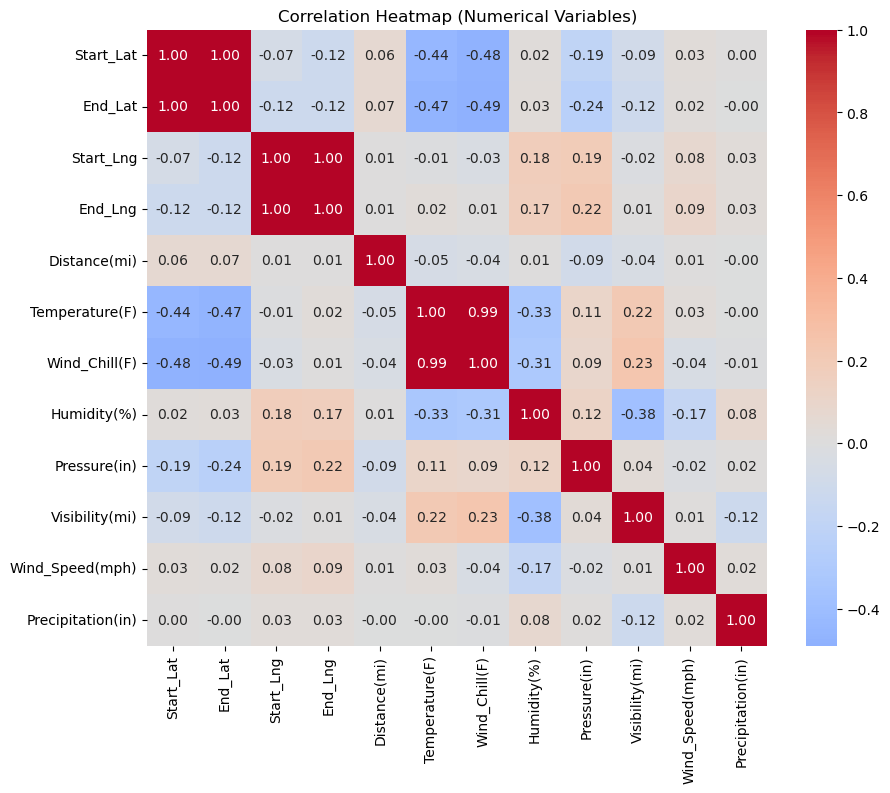

In [10]:

corr_matrix = df[num_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap (Numerical Variables)")
plt.show()

### boxplots and violin plots by severity index

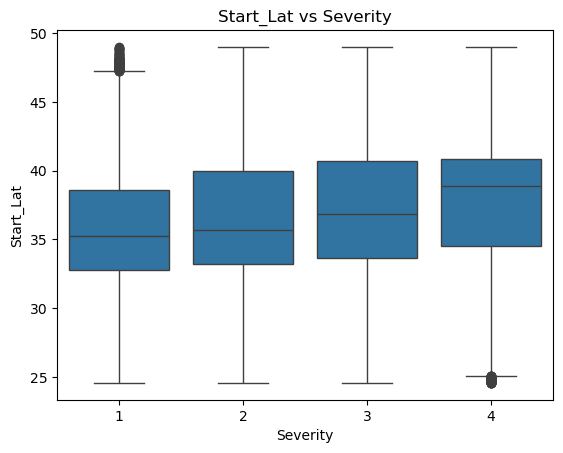

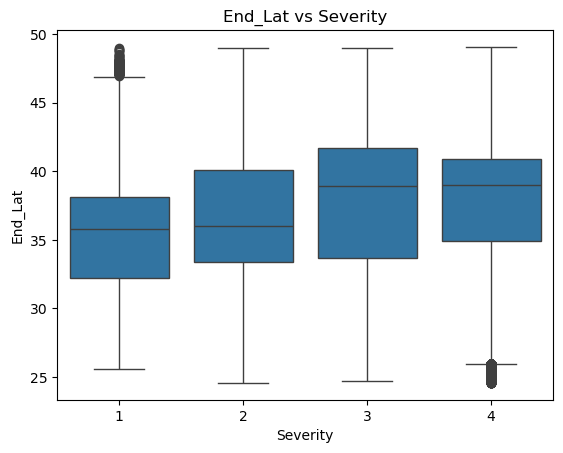

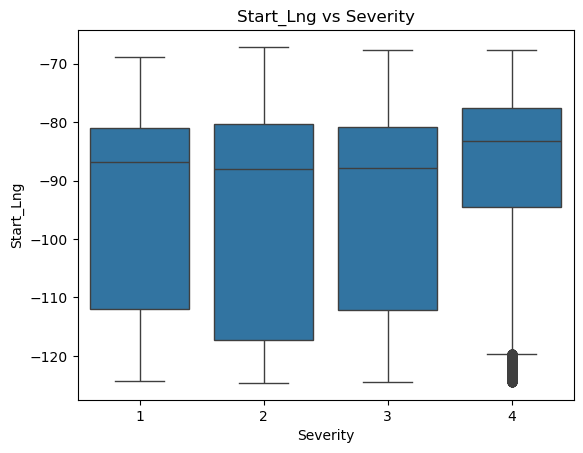

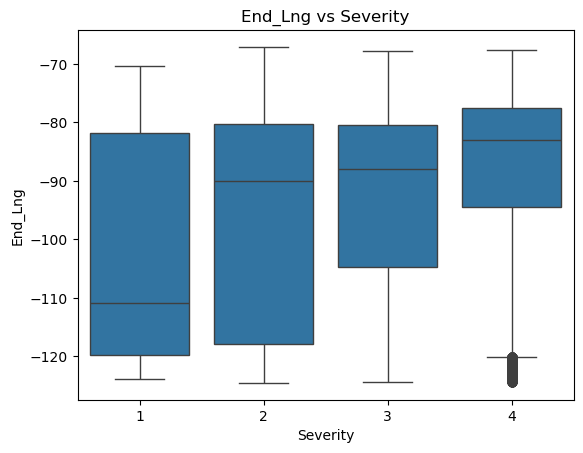

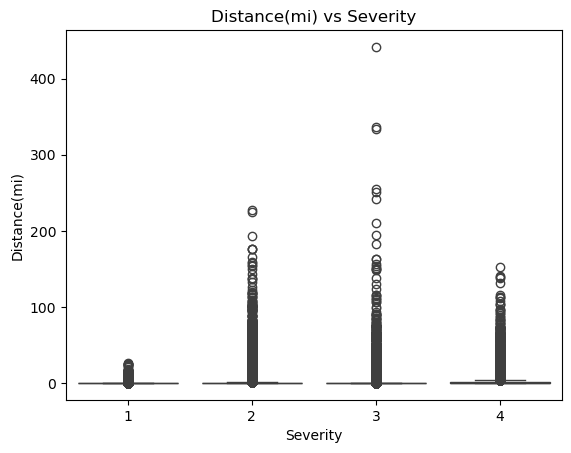

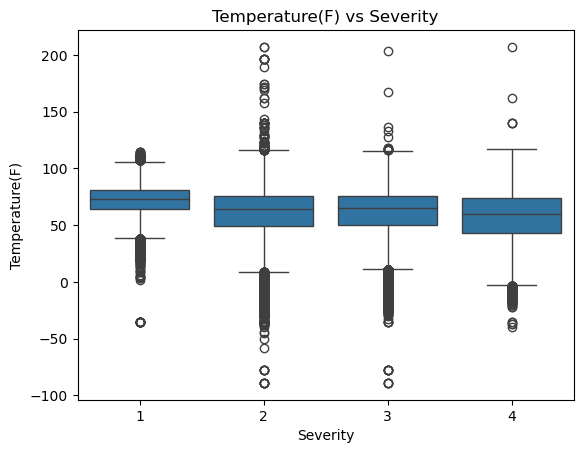

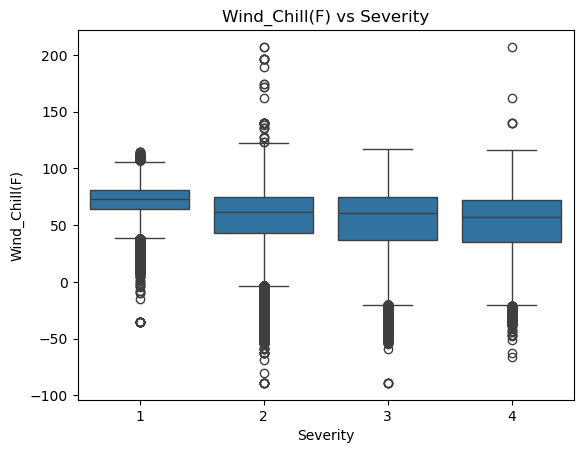

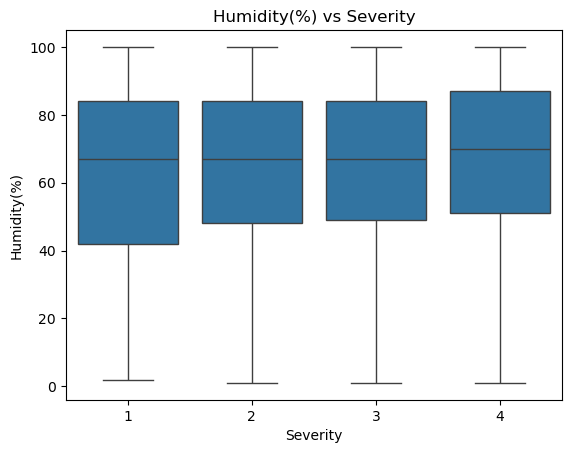

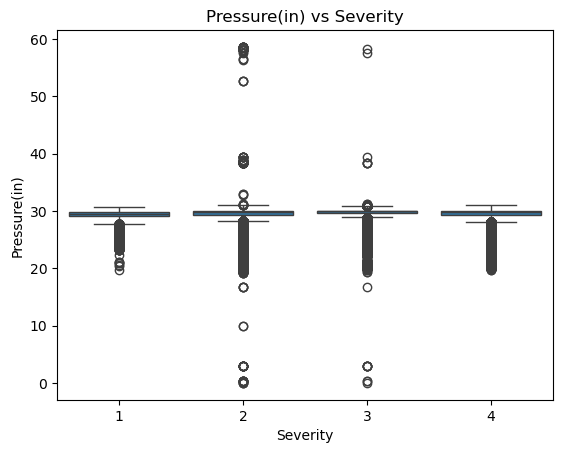

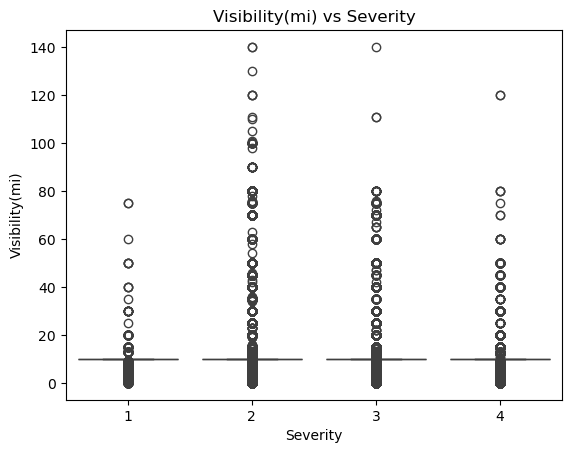

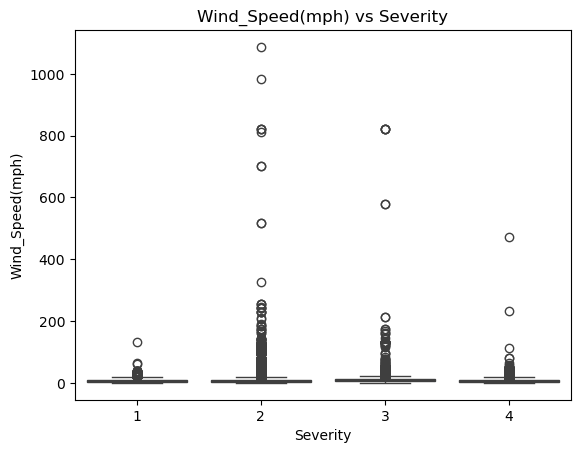

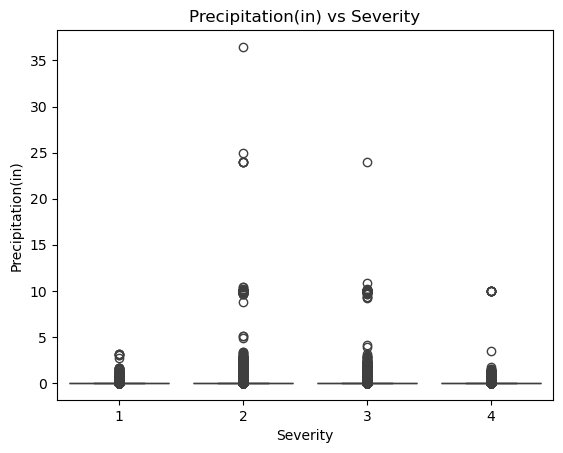

In [11]:
for col in num_vars:
    plt.figure()
    sns.boxplot(x="Severity", y=col, data=df)
    
    plt.title(f"{col} vs Severity")
    plt.xlabel("Severity")
    plt.ylabel(col)
    
    plt.show()

## categorical features
In this subsection, we analyze categorical variables. For each variable, we count the number of unique values and display them. If the cardinality is less than ten, we also plot boxplots by severity values.

In [102]:
#df.dtypes
cat_vars = ["Source", "Street", "City", "County", "State", "Zipcode", "Country", "Timezone", "Airport_Code","Wind_Direction", "Weather_Condition", "Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Turning_Loop", "Sunrise_Sunset", "Civil_Twilight", "Nautical_Twilight", "Astronomical_Twilight" ]

In [14]:
df[cat_vars]

,Source,Street,City,County,State,Zipcode,Country,Timezone,Airport_Code,Wind_Direction,...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,Source2,I-70 E,Dayton,Montgomery,OH,45424,US,US/Eastern,KFFO,Calm,...,False,False,False,False,False,False,Night,Night,Night,Night
1,Source2,Brice Rd,Reynoldsburg,Franklin,OH,43068-3402,US,US/Eastern,KCMH,Calm,...,False,False,False,False,False,False,Night,Night,Night,Day
2,Source2,State Route 32,Williamsburg,Clermont,OH,45176,US,US/Eastern,KI69,SW,...,False,False,False,False,True,False,Night,Night,Day,Day
3,Source2,I-75 S,Dayton,Montgomery,OH,45417,US,US/Eastern,KDAY,SW,...,False,False,False,False,False,False,Night,Day,Day,Day
4,Source2,Miamisburg Centerville Rd,Dayton,Montgomery,OH,45459,US,US/Eastern,KMGY,SW,...,False,False,False,False,True,False,Day,Day,Day,Day
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7728389,Source1,Pomona Fwy E,Riverside,Riverside,CA,92501,US,US/Pacific,KRAL,W,...,False,False,False,False,False,False,Day,Day,Day,Day
7728390,Source1,I-8 W,San Diego,San Diego,CA,92108,US,US/Pacific,KMYF,SW,...,False,False,False,False,False,False,Day,Day,Day,Day
7728391,Source1,Garden Grove Fwy,Orange,Orange,CA,92866,US,US/Pacific,KSNA,SSW,...,False,False,False,False,False,False,Day,Day,Day,Day
7728392,Source1,San Diego Fwy S,Culver City,Los Angeles,CA,90230,US,US/Pacific,KSMO,SW,...,False,False,False,False,False,False,Day,Day,Day,Day



Column: Source
Unique values: 3
Source
Source1    4325632
Source2    3305373
Source3      97389
Name: count, dtype: int64


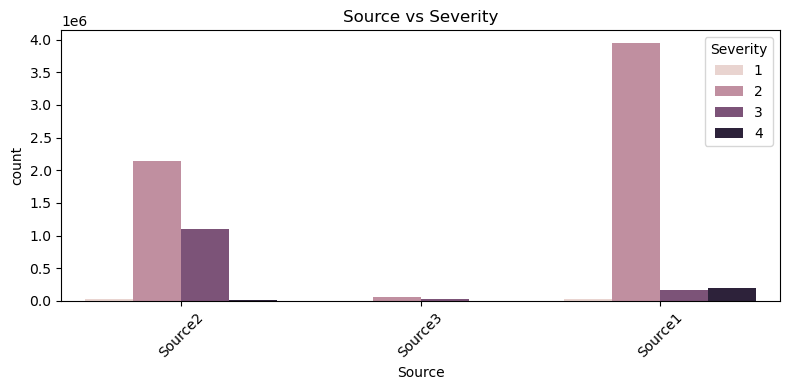


Column: Street
Unique values: 336306
Street
I-95 N     78430
I-95 S     74528
I-5 N      71968
I-10 E     55572
I-10 W     53725
I-5 S      51781
I-80 W     39662
I-80 E     36113
I-405 N    32364
I-75 N     28166
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: City
Unique values: 13678
City
Miami          186917
Houston        169609
Los Angeles    156491
Charlotte      138652
Dallas         130939
Orlando        109733
Austin          97359
Raleigh         86079
Nashville       72930
Baton Rouge     71588
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: County
Unique values: 1871
County
Los Angeles       526851
Miami-Dade        251601
Orange            241275
Harris            181196
Dallas            157024
Mecklenburg       147265
Montgomery        136788
Wake              117890
San Bernardino    109631
Travis            107881
Name: count, dtype: int64


...


Column: State
Unique values: 49
State
CA    1741433
FL     880192
TX     582837
SC     382557
NY     347960
NC     338199
VA     303301
PA     296620
MN     192084
OR     179660
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: Zipcode
Unique values: 825094
Zipcode
91761    11247
91706    10022
92407     8922
92507     8850
33186     8375
32819     7461
91765     7377
33169     7106
90023     7066
92324     7010
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: Country
Unique values: 1
Country
US    7728394
Name: count, dtype: int64


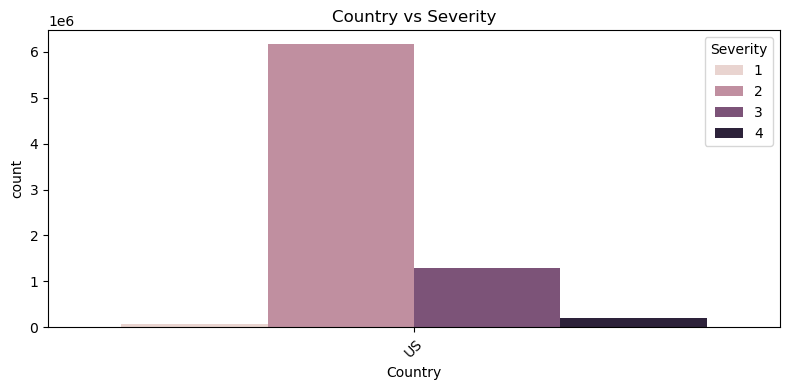


Column: Timezone
Unique values: 4
Timezone
US/Eastern     3580167
US/Pacific     2062984
US/Central     1645616
US/Mountain     431819
None              7808
Name: count, dtype: int64


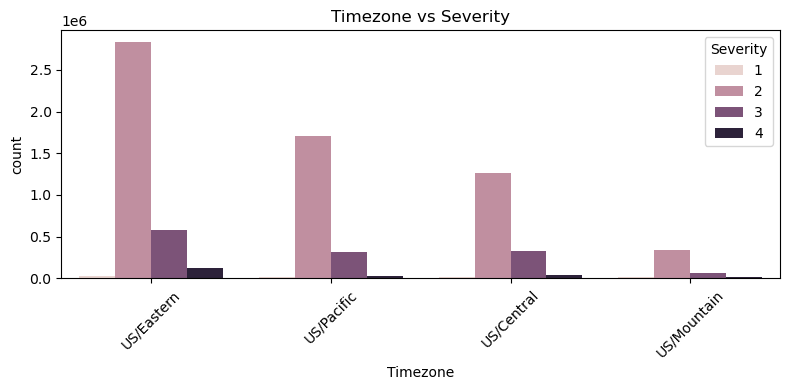


Column: Airport_Code
Unique values: 2045
Airport_Code
KCQT    118332
KRDU    107267
KMCJ    101786
KBNA     98926
KCLT     97273
KORL     82480
KMIA     81358
KBTR     78304
KOPF     70665
KDAL     69353
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: Wind_Direction
Unique values: 24
Wind_Direction
CALM    961624
S       419989
SSW     384840
W       383913
WNW     378781
NW      369352
Calm    368557
SW      364470
WSW     353806
SSE     349110
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: Weather_Condition
Unique values: 144
Weather_Condition
Fair                2560802
Mostly Cloudy       1016195
Cloudy               817082
Clear                808743
Partly Cloudy        698972
Overcast             382866
Light Rain           352957
Scattered Clouds     204829
None                 173459
Light Snow           128680
Name: count, dtype: int64


<Figure size 800x400 with 0 Axes>


Column: Amenity
Unique values: 2
Amenity
False    7632060
True       96334
Name: count, dtype: int64


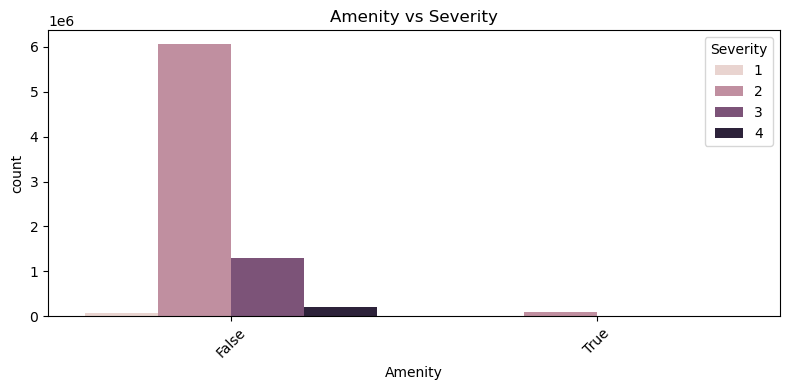


Column: Bump
Unique values: 2
Bump
False    7724880
True        3514
Name: count, dtype: int64


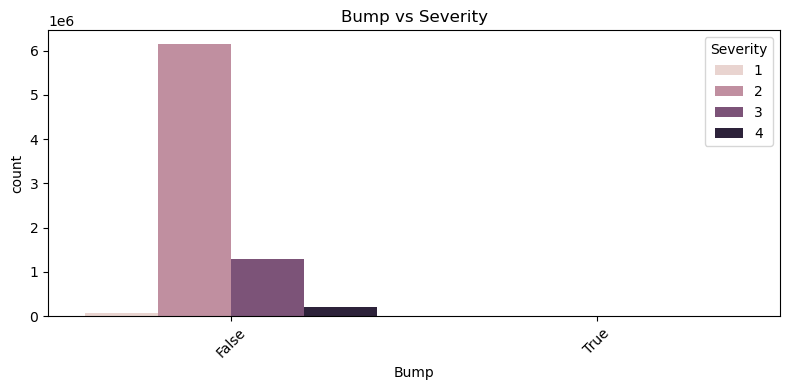


Column: Crossing
Unique values: 2
Crossing
False    6854631
True      873763
Name: count, dtype: int64


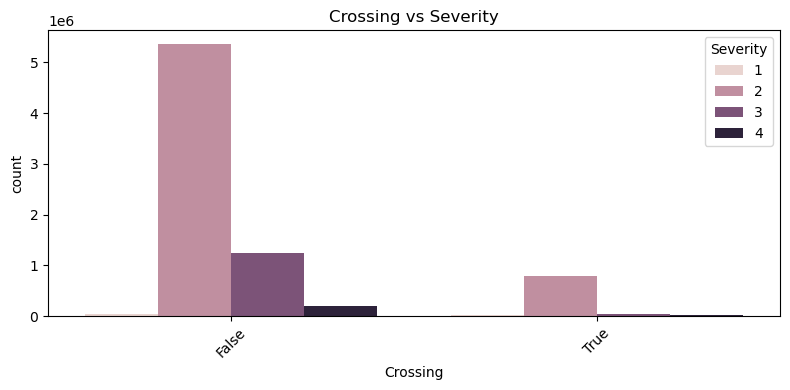


Column: Give_Way
Unique values: 2
Give_Way
False    7691812
True       36582
Name: count, dtype: int64


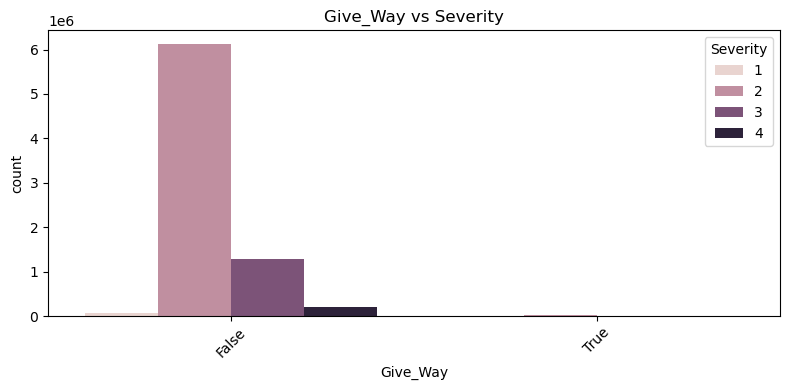


Column: Junction
Unique values: 2
Junction
False    7157052
True      571342
Name: count, dtype: int64


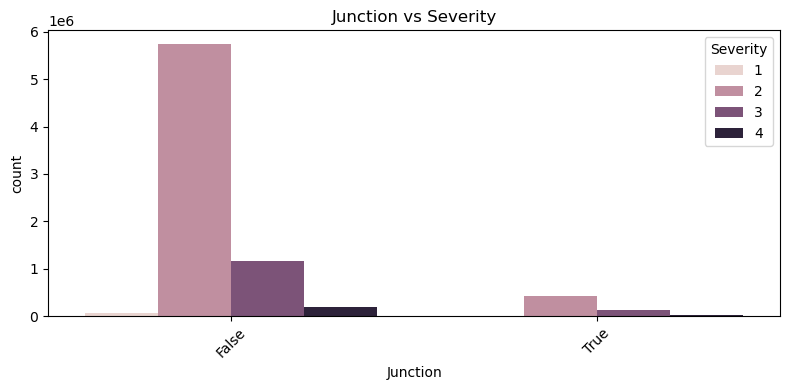


Column: No_Exit
Unique values: 2
No_Exit
False    7708849
True       19545
Name: count, dtype: int64


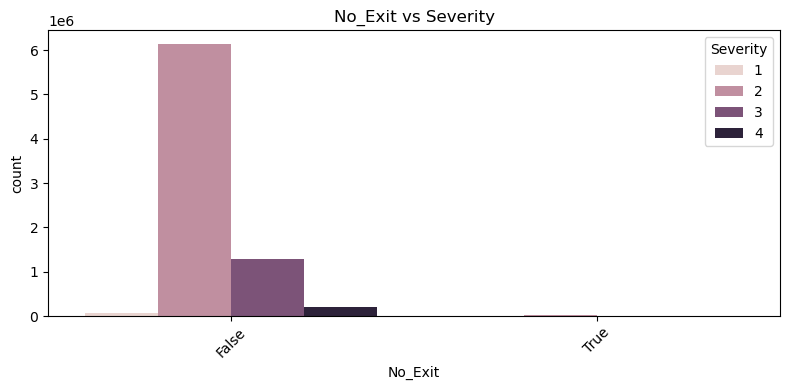


Column: Railway
Unique values: 2
Railway
False    7661415
True       66979
Name: count, dtype: int64


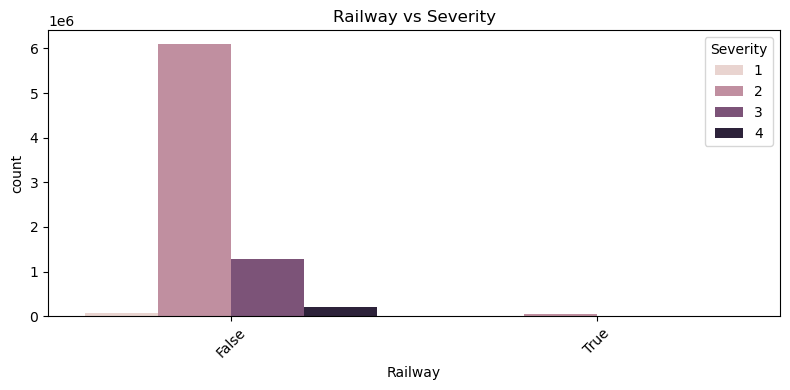


Column: Roundabout
Unique values: 2
Roundabout
False    7728145
True         249
Name: count, dtype: int64


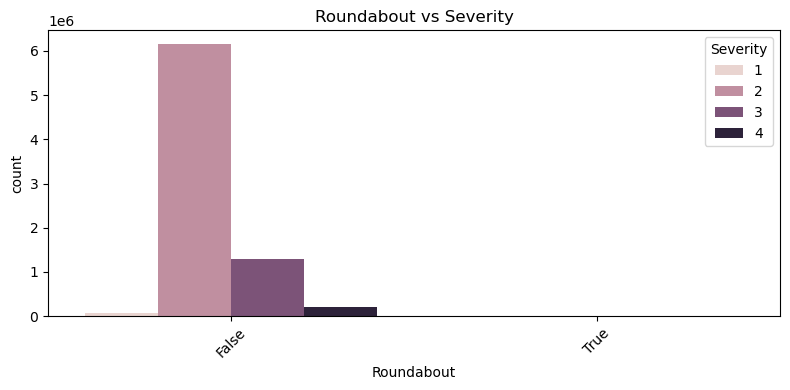


Column: Station
Unique values: 2
Station
False    7526493
True      201901
Name: count, dtype: int64


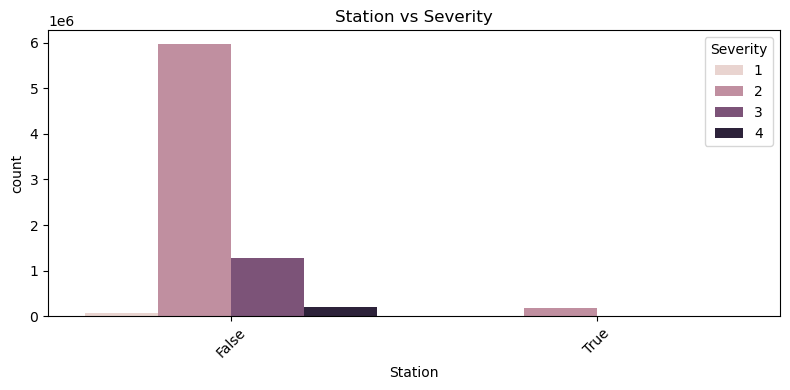


Column: Stop
Unique values: 2
Stop
False    7514023
True      214371
Name: count, dtype: int64


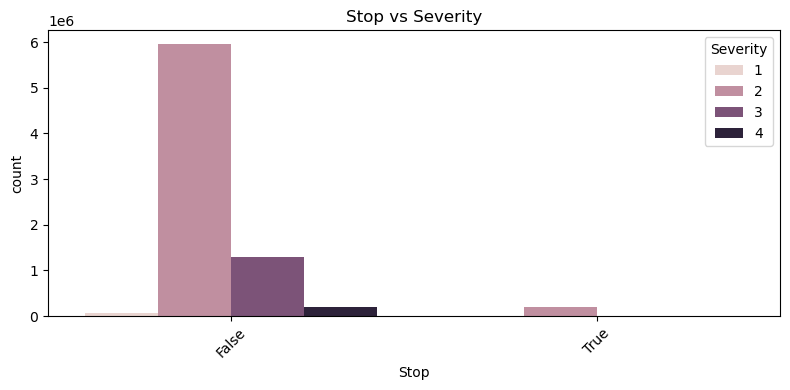


Column: Traffic_Calming
Unique values: 2
Traffic_Calming
False    7720796
True        7598
Name: count, dtype: int64


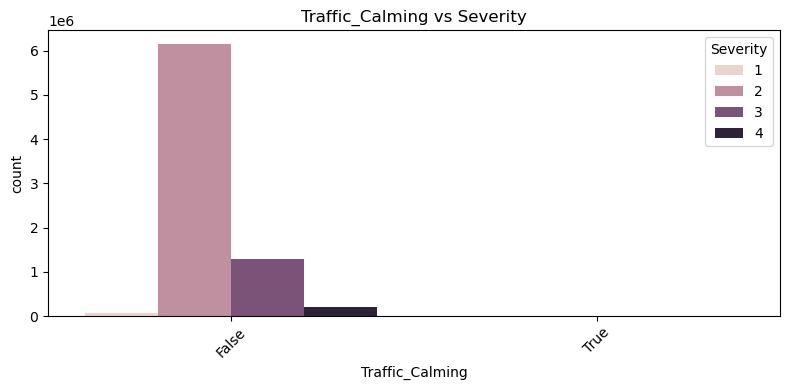


Column: Traffic_Signal
Unique values: 2
Traffic_Signal
False    6584622
True     1143772
Name: count, dtype: int64


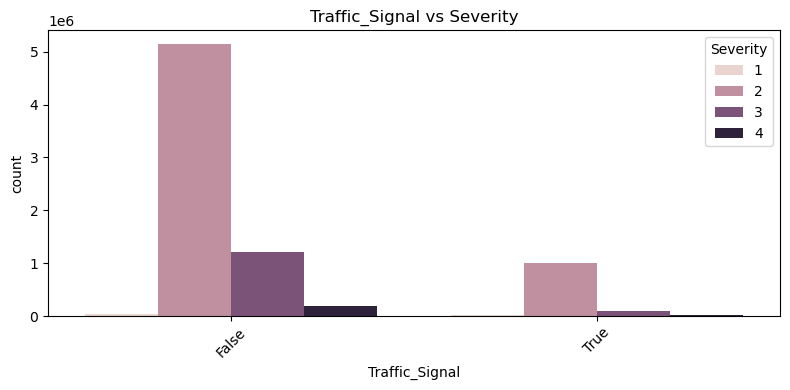


Column: Turning_Loop
Unique values: 1
Turning_Loop
False    7728394
Name: count, dtype: int64


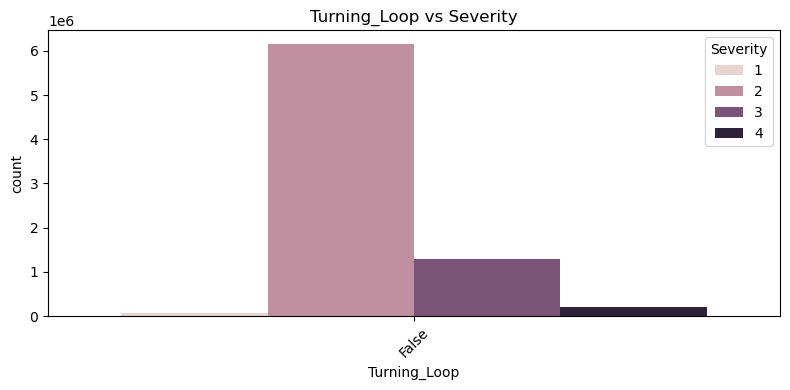


Column: Sunrise_Sunset
Unique values: 2
Sunrise_Sunset
Day      5334553
Night    2370595
None       23246
Name: count, dtype: int64


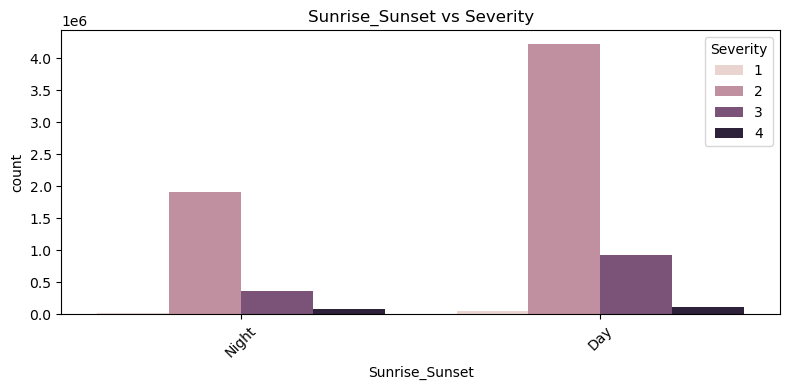


Column: Civil_Twilight
Unique values: 2
Civil_Twilight
Day      5695619
Night    2009529
None       23246
Name: count, dtype: int64


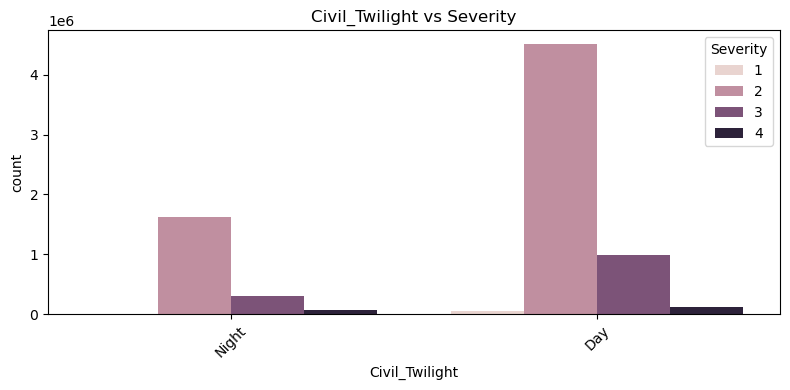


Column: Nautical_Twilight
Unique values: 2
Nautical_Twilight
Day      6076156
Night    1628992
None       23246
Name: count, dtype: int64


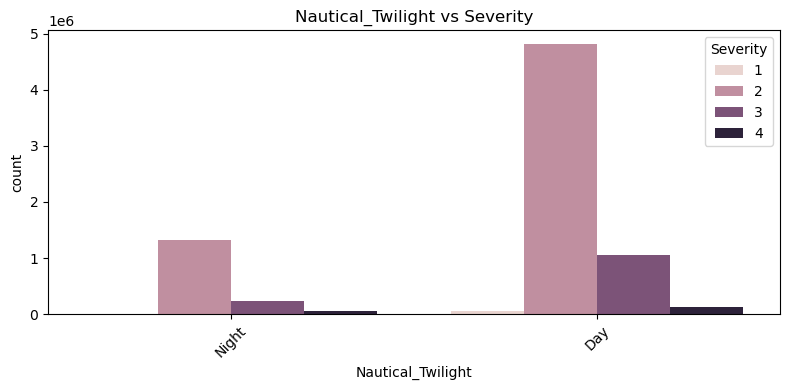


Column: Astronomical_Twilight
Unique values: 2
Astronomical_Twilight
Day      6377548
Night    1327600
None       23246
Name: count, dtype: int64


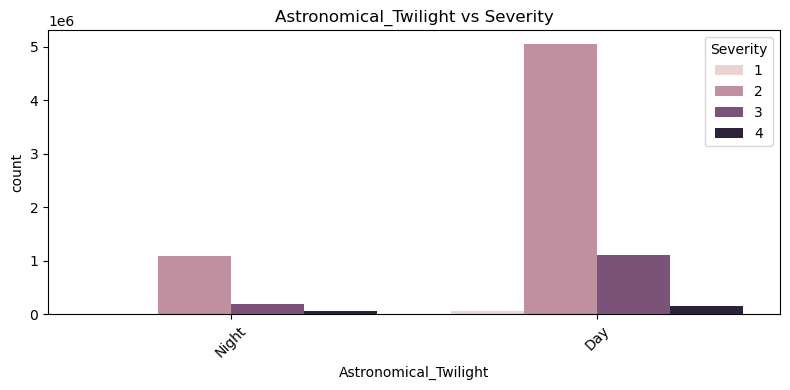

In [105]:
for col in cat_vars:
    print("\n" + "="*40)
    print(f"Column: {col}")
    
    # Basic info
    print("Unique values:", df[col].nunique())
    print(df[col].value_counts(dropna=False).head(10))
    
    # --- Plot logic ---
    n_unique = df[col].nunique()
    
    plt.figure(figsize=(8, 4))
    
    if n_unique <= 10:
        # Low-cardinality → full plot
        sns.countplot(x=col, hue="Severity", data=df)
        plt.xticks(rotation=45)
        plt.title(f"{col} vs Severity")
    
    
    plt.tight_layout()
    plt.show()

# Data Cleaning
In this section, based on a more comprehensive understanding of the data, we handle missing values and apply transformations to obtain a cleaner dataset.

The variables "Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Direction", and "Weather_Condition" have a small percentage of missing values. Since the dataset is large and, from the previous histograms, the distribution of missing data by severity does not differ significantly from that of non-missing data, it is reasonable to remove rows with these missing values without introducing significant bias.

In [16]:
df_copy = df.dropna(subset = ["Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Direction", "Weather_Condition"]).copy()


Here, since the weather condition variable has too many categories, we group them into a set of basic categories: clear, cloudy, rain, fog, snow, dust/smoke, and extreme. Wind is ignored, as wind speed is already captured by a dedicated variable.

In [17]:
df_copy["Weather_Condition"].unique()

array(['Light Rain', 'Overcast', 'Mostly Cloudy', 'Rain', 'Light Snow',
       'Haze', 'Scattered Clouds', 'Partly Cloudy', 'Clear', 'Snow',
       'Light Freezing Drizzle', 'Light Drizzle', 'Fog', 'Shallow Fog',
       'Heavy Rain', 'Light Freezing Rain', 'Cloudy', 'Drizzle',
       'Light Rain Showers', 'Mist', 'Smoke', 'Patches of Fog',
       'Light Freezing Fog', 'Light Haze', 'Light Thunderstorms and Rain',
       'Thunderstorms and Rain', 'Fair', 'Volcanic Ash', 'Blowing Sand',
       'Blowing Dust / Windy', 'Widespread Dust', 'Fair / Windy',
       'Rain Showers', 'Light Rain / Windy', 'Hail', 'Heavy Drizzle',
       'Showers in the Vicinity', 'Light Rain Shower',
       'Light Rain with Thunder', 'Mostly Cloudy / Windy',
       'Partly Cloudy / Windy', 'Thunder in the Vicinity', 'T-Storm',
       'Heavy Thunderstorms and Rain', 'Thunderstorm', 'Thunder',
       'Heavy T-Storm', 'Funnel Cloud', 'Heavy T-Storm / Windy',
       'Blowing Snow', 'Light Thunderstorms and Snow', 'Hea

In [18]:
weather_map = {
    # --- CLEAR ---
    "Clear": "clear",
    "Fair": "clear",
    "Fair / Windy": "clear",

    # --- CLOUDY ---
    "Cloudy": "cloudy",
    "Cloudy / Windy": "cloudy",
    "Overcast": "cloudy",
    "Mostly Cloudy": "cloudy",
    "Mostly Cloudy / Windy": "cloudy",
    "Partly Cloudy": "cloudy",
    "Partly Cloudy / Windy": "cloudy",
    "Scattered Clouds": "cloudy",

    # --- RAIN / DRIZZLE ---
    "Rain": "rain",
    "Rain / Windy": "rain",
    "Light Rain": "rain",
    "Light Rain / Windy": "rain",
    "Heavy Rain": "rain",
    "Heavy Rain / Windy": "rain",
    "Drizzle": "rain",
    "Drizzle / Windy": "rain",
    "Light Drizzle": "rain",
    "Light Drizzle / Windy": "rain",
    "Heavy Drizzle": "rain",
    "Rain Showers": "rain",
    "Rain Shower": "rain",
    "Rain Shower / Windy": "rain",
    "Light Rain Shower": "rain",
    "Light Rain Shower / Windy": "rain",
    "Light Rain Showers": "rain",
    "Heavy Rain Showers": "rain",
    "Heavy Rain Shower": "rain",
    "Heavy Rain Shower / Windy": "rain",
    "Showers in the Vicinity": "rain",

    # --- FOG / LOW VISIBILITY ---
    "Fog": "fog",
    "Fog / Windy": "fog",
    "Light Fog": "fog",
    "Light Freezing Fog": "fog",
    "Shallow Fog": "fog",
    "Shallow Fog / Windy": "fog",
    "Patches of Fog": "fog",
    "Patches of Fog / Windy": "fog",
    "Partial Fog": "fog",
    "Partial Fog / Windy": "fog",
    "Mist": "fog",
    "Mist / Windy": "fog",
    "Haze": "fog",
    "Haze / Windy": "fog",
    "Light Haze": "fog",
    "Drizzle and Fog": "fog",

    # --- SNOW ---
    "Snow": "snow",
    "Snow / Windy": "snow",
    "Light Snow": "snow",
    "Light Snow / Windy": "snow",
    "Heavy Snow": "snow",
    "Heavy Snow / Windy": "snow",
    "Snow Showers": "snow",
    "Light Snow Showers": "snow",
    "Light Snow Shower": "snow",
    "Light Snow Shower / Windy": "snow",
    "Blowing Snow": "snow",
    "Blowing Snow / Windy": "snow",
    "Blowing Snow Nearby": "snow",
    "Low Drifting Snow": "snow",
    "Drifting Snow": "snow",
    "Drifting Snow / Windy": "snow",
    "Light Blowing Snow": "snow",
    "Heavy Blowing Snow": "snow",
    "Snow Grains": "snow",
    "Light Snow Grains": "snow",

    # --- STORM / THUNDER ---
    "Thunderstorm": "storm",
    "Light Thunderstorm": "storm",
    "Thunderstorms and Rain": "storm",
    "Light Thunderstorms and Rain": "storm",
    "Heavy Thunderstorms and Rain": "storm",
    "Thunderstorms and Snow": "storm",
    "Light Thunderstorms and Snow": "storm",
    "Heavy Thunderstorms and Snow": "storm",
    "T-Storm": "storm",
    "T-Storm / Windy": "storm",
    "Heavy T-Storm": "storm",
    "Heavy T-Storm / Windy": "storm",
    "Thunder": "storm",
    "Thunder / Windy": "storm",
    "Thunder in the Vicinity": "storm",
    "Light Rain with Thunder": "storm",
    "Light Snow with Thunder": "storm",
    "Snow and Thunder": "storm",
    "Snow and Thunder / Windy": "storm",
    "Heavy Snow with Thunder": "storm",
    "Thunder and Hail": "storm",
    "Thunder and Hail / Windy": "storm",
    "Thunder / Wintry Mix": "storm",
    "Thunder / Wintry Mix / Windy": "storm",
    "Sleet and Thunder": "storm",
    "Heavy Sleet and Thunder": "storm",
    "Heavy Thunderstorms with Small Hail": "storm",

    # --- ICE / FREEZING / HAIL / SLEET ---
    "Sleet": "ice",
    "Sleet / Windy": "ice",
    "Light Sleet": "ice",
    "Light Sleet / Windy": "ice",
    "Heavy Sleet": "ice",
    "Heavy Sleet / Windy": "ice",
    "Ice Pellets": "ice",
    "Light Ice Pellets": "ice",
    "Heavy Ice Pellets": "ice",
    "Freezing Rain": "ice",
    "Freezing Rain / Windy": "ice",
    "Light Freezing Rain": "ice",
    "Light Freezing Rain / Windy": "ice",
    "Heavy Freezing Rain": "ice",
    "Heavy Freezing Rain / Windy": "ice",
    "Freezing Drizzle": "ice",
    "Light Freezing Drizzle": "ice",
    "Heavy Freezing Drizzle": "ice",
    "Wintry Mix": "ice",
    "Wintry Mix / Windy": "ice",
    "Snow and Sleet": "ice",
    "Snow and Sleet / Windy": "ice",
    "Light Snow and Sleet": "ice",
    "Light Snow and Sleet / Windy": "ice",
    "Rain and Sleet": "ice",
    "Hail": "ice",
    "Small Hail": "ice",
    "Light Hail": "ice",

    # --- DUST / SMOKE / SAND ---
    "Smoke": "dust_smoke",
    "Smoke / Windy": "dust_smoke",
    "Heavy Smoke": "dust_smoke",
    "Blowing Dust": "dust_smoke",
    "Blowing Dust / Windy": "dust_smoke",
    "Blowing Sand": "dust_smoke",
    "Widespread Dust": "dust_smoke",
    "Widespread Dust / Windy": "dust_smoke",
    "Dust Whirls": "dust_smoke",
    "Sand / Windy": "dust_smoke",
    "Sand / Dust Whirlwinds": "dust_smoke",
    "Sand / Dust Whirlwinds / Windy": "dust_smoke",
    "Sand / Dust Whirls Nearby": "dust_smoke",

    # --- EXTREME ---
    "Tornado": "extreme",
    "Funnel Cloud": "extreme",
    "Volcanic Ash": "extreme",
    "Squalls": "extreme",
    "Squalls / Windy": "extreme",
}

In [19]:
df_copy["Weather_grouped"] = (
    df_copy["Weather_Condition"]
    .map(weather_map)
    .fillna("other")
)

Precipitation has a relatively high percentage of missing values (28%), so it is not appropriate to delete all rows with missing data. If the weather condition category indicates no precipitation, the missing value is replaced with 0; otherwise, it is imputed with the mean value.

In [ ]:
mean_precip = df_copy["Precipitation(in)"].mean()
mask = df_copy["Precipitation(in)"].isna()
df_copy.loc[mask & df_copy["Weather_grouped"].isin(["rain", "snow", "ice", "storm"]), "Precipitation(in)"] = mean_precip
df_copy.loc[mask & ~df_copy["Weather_grouped"].isin(["rain", "snow", "ice","storm"]), "Precipitation(in)"] = 0.0

Wind speed values that are NaN all correspond, based on the dataset, to a value of “Calm” in wind direction; therefore, all NaNs are replaced with 0.

In [21]:
df_copy["Wind_Speed(mph)"] = df_copy["Wind_Speed(mph)"].fillna(0.0)

Categories in Wind_Direction are unified (e.g., Calm/CALM, North/N, etc.).


In [22]:
df_copy["Wind_Direction"] = df_copy["Wind_Direction"].replace("Calm", "CALM")
df_copy["Wind_Direction"] = df_copy["Wind_Direction"].replace("North", "N")
df_copy["Wind_Direction"] = df_copy["Wind_Direction"].replace("South", "S")
df_copy["Wind_Direction"] = df_copy["Wind_Direction"].replace("East", "E")
df_copy["Wind_Direction"] = df_copy["Wind_Direction"].replace("West", "W")
df_copy["Wind_Direction"] = df_copy["Wind_Direction"].replace("Variable", "VAR")

Here, meaningful features are extracted from the Start_Time variable, namely Hour, Weekday, and Month. These features can be important for predicting accident severity, for example because traffic peaks occur at specific hours.

In [23]:
df_copy["Start_Time"] = (
    df_copy["Start_Time"]
    .astype(str)
    .str.replace(r"\.\d+", "", regex=True)
)
df_copy['Start_Time'] = pd.to_datetime(df_copy['Start_Time'], errors='coerce')
df_copy['Hour'] = df_copy['Start_Time'].dt.hour
df_copy['Weekday'] = df_copy['Start_Time'].dt.weekday
df_copy['Month'] = df_copy['Start_Time'].dt.month

All variables with values Day/Night that indicate the level of light are replaced by a single ordinal variable called light.

In [24]:
df_copy["light"] = np.nan

df_copy.loc[df_copy["Sunrise_Sunset"] == "Day", "light"] = 3
df_copy.loc[(df_copy["Sunrise_Sunset"] != "Day") & (df_copy["Civil_Twilight"] == "Day"), "light"] = 2
df_copy.loc[(df_copy["Civil_Twilight"] != "Day") & (df_copy["Nautical_Twilight"] == "Day"), "light"] = 1
df_copy.loc[(df_copy["Nautical_Twilight"] != "Day"), "light"] = 0

df_copy.loc[df_copy["light"].isna() & (df_copy["Hour"].between(8, 16)), "light"] = 3
df_copy.loc[df_copy["light"].isna() & (df_copy["Hour"].between(6, 18)), "light"] = 2
df_copy.loc[df_copy["light"].isna() & (df_copy["Hour"].between(5, 19)), "light"] = 1
df_copy.loc[df_copy["light"].isna(), "light"] = 0

We split the dataset into target and covariates (X, y), and remove columns that are not useful or appropriate for prediction.

The following variables are dropped for the reasons listed below:

- **Start_Time** → already used to extract Hour, Weekday, and Month; no longer needed  
- **End_Time** → not useful; also unavailable at prediction time  
- **Sunrise_Sunset, Civil_Twilight, Nautical_Twilight, Astronomical_Twilight** → information already captured in the *light* variable  
- **Distance(mi)** → unknown at prediction time  
- **Source, Weather_Timestamp, Airport_Code** → not relevant  
- **End_Lat, End_Lng** → perfectly correlated with Start_Lat and Start_Lng respectively  
- **Wind_Chill(F)** → highly correlated with Temperature and has more missing values, so it is preferable to drop it  
- **Street, City, State, County, Zipcode** → very high cardinality; geographical information is already encoded in Start_Lat and Start_Lng  
- **Country** → only one value  
- **Timezone** → not relevant  
- **Description** → unknown at prediction time  



In [25]:
y = df_copy["Severity"]
X = df_copy.drop(columns = ["Severity", "Start_Time", "End_Time", "Sunrise_Sunset", "Civil_Twilight",	"Nautical_Twilight", "Astronomical_Twilight", "Distance(mi)", "Source","End_Lat", "End_Lng", "Wind_Chill(F)", "Street", "City", "Airport_Code", "Weather_Timestamp", "Country", "County", "Description", "Zipcode", "Timezone","Weather_Condition","State", "Turning_Loop"])


In [26]:
num_vars = ["Start_Lat", "Start_Lng", "Temperature(F)", "Humidity(%)", "Pressure(in)", "Visibility(mi)", "Wind_Speed(mph)", "Precipitation(in)"]
cat_vars = ["Wind_Direction", "Weather_grouped"]
bool_ord_vars = ["Amenity", "Bump", "Crossing", "Give_Way", "Junction", "No_Exit", "Railway", "Roundabout", "Station", "Stop", "Traffic_Calming", "Traffic_Signal", "Hour", "Weekday", "Month", "light"]

# Modeling

## Model Selection

In this section, we split the dataset into training and test sets. We also modify the target variable by mapping severity values below 4 to 0 and values equal to 4 to 1. The goal is to build a model capable of predicting high-severity accidents (level 4).

Model selection is then performed using cross-validation on the training set.

In [89]:
y_binary = (y == 4).astype(int)

In [90]:
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
X_train, X_test, y_train, y_test = train_test_split(X, y_binary, test_size=0.3, random_state=42, stratify=y)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)


Train shape: (5219781, 26) (5219781,)
Test shape: (2237050, 26) (2237050,)


In [91]:
y_train.value_counts()

Severity
0    5083884
1     135897
Name: count, dtype: int64

In this step, we use a sampled version of the training set obtained from the previous split. This is done because the full training set is very large, leading to high computational cost and long training times.

When sampling from the training set, all samples belonging to class 1 (severity 4) are retained, as this class is already underrepresented.

In [92]:
from imblearn.under_sampling import RandomUnderSampler

sampling_strategy = {
    0: 1000000,   
    1: 135897,
}

rus = RandomUnderSampler(
    sampling_strategy=sampling_strategy,
    random_state=42
)

X_train, y_train = rus.fit_resample(X_train, y_train)
print('Train shape:', X_train.shape, y_train.shape)
print('Test shape:', X_test.shape, y_test.shape)


Train shape: (1135897, 26) (1135897,)
Test shape: (2237050, 26) (2237050,)


### Logistic Regression

The first model used is Logistic Regression with an L2 (ridge) penalty. The pipeline is structured as follows: numerical features are scaled, categorical features are one-hot encoded, and synthetic samples of the underrepresented class are generated (via interpolation) to balance the dataset. The model is then trained on this processed data.

To determine the optimal value of the regularization parameter, a grid search with cross-validation is performed, using accuracy as the evaluation metric.

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_vars),
        ('cat', OneHotEncoder(handle_unknown="ignore"), cat_vars),
        ('boolord', 'passthrough', bool_ord_vars)
    ]
)

logreg = LogisticRegression(
    penalty='l2',
    solver='lbfgs',
    max_iter=5000
)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', logreg)
])

grid = GridSearchCV(
    pipeline,
    {'model__C': np.logspace(-3, 3, 10)},
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

# Fit
grid.fit(X_train, y_train)

# Print results
print("Best params:", grid.best_params_)
print("Best CV score:", grid.best_score_)



Fitting 5 folds for each of 10 candidates, totalling 50 fits
[CV] END .....................................model__C=0.001; total time= 1.8min
[CV] END .....................................model__C=0.001; total time= 1.9min
[CV] END .....................................model__C=0.001; total time= 1.9min
[CV] END .....................................model__C=0.001; total time= 2.0min
[CV] END .....................................model__C=0.001; total time= 2.0min
[CV] END ......................model__C=0.004641588833612777; total time= 2.0min
[CV] END ......................model__C=0.004641588833612777; total time= 2.1min
[CV] END ......................model__C=0.004641588833612777; total time= 2.1min
[CV] END ......................model__C=0.004641588833612777; total time= 2.1min
[CV] END ......................model__C=0.004641588833612777; total time= 2.2min
[CV] END ......................model__C=0.021544346900318832; total time= 2.1min
[CV] END ......................model__C=0.021544

/Users/sara/miniconda3/envs/AppStat/lib/python3.13/site-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


[CV] END .........................model__C=2.154434690031882; total time= 2.5min
[CV] END .........................model__C=2.154434690031882; total time= 2.5min
[CV] END .........................model__C=2.154434690031882; total time= 2.6min
[CV] END .........................model__C=2.154434690031882; total time= 3.0min
[CV] END ......................................model__C=10.0; total time= 2.4min
[CV] END ......................................model__C=10.0; total time= 2.4min
[CV] END ......................................model__C=10.0; total time= 2.5min
[CV] END ......................................model__C=10.0; total time= 2.6min
[CV] END .........................model__C=46.41588833612773; total time= 2.3min
[CV] END ......................................model__C=10.0; total time= 2.6min
[CV] END .........................model__C=46.41588833612773; total time= 2.5min
[CV] END .........................model__C=46.41588833612773; total time= 2.7min
[CV] END ...................

### Random forest

The second model used is a Random Forest classifier. The pipeline is structured similarly to the previous model: numerical features are scaled, categorical features are one-hot encoded, and ordinal/boolean features are passed through unchanged. Synthetic samples of the underrepresented class are then generated using SMOTE to balance the dataset.

The model is evaluated using 5-fold cross-validation on the training set, with accuracy as the evaluation metric. The mean cross-validation accuracy is computed to assess the overall performance of the model.


In [96]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_vars),
        ('cat', OneHotEncoder(handle_unknown="ignore"), cat_vars),
        ('boolord', 'passthrough', bool_ord_vars)
    ]
)

rf = RandomForestClassifier(
        n_jobs=-1,
        verbose=1,
        random_state=42)
    

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', rf)
])

# 5-fold cross-validation
scores = cross_val_score(
    pipeline,
    X_train,
    y_train,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

# Print results
print("CV Accuracy scores:", scores)
print("Mean CV accuracy:", scores.mean())


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  1.8min
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  1.9min
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:  2.0min
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  7.6min finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  7.7min fin

CV Accuracy scores: [0.89226604 0.89298354 0.89182099 0.8916009  0.89284221]
Mean CV accuracy: 0.8923027346281286


### Final Model: Random Forest

Since the Random Forest model achieved the highest cross-validation score, it is selected as the final model. It is then trained on the whole training set and evaluated on the test set.

In this implementation, preprocessing is applied explicitly. Numerical features are scaled, categorical features are one-hot encoded The transformed data is then converted back into a DataFrame using the generated feature names, so that these can later be used for feature importance analysis.

Finally, the model is evaluated on the test set using a confusion matrix and a classification report, including precision, recall, and F1-score.

In [97]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_vars),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_vars),
        ("boolord", "passthrough", bool_ord_vars)
    ]
)

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

feature_names = preprocessor.get_feature_names_out()

X_train_processed = pd.DataFrame(
    X_train_processed,
    columns=feature_names,
    index=X_train.index
)

X_test_processed = pd.DataFrame(
    X_test_processed,
    columns=feature_names,
    index=X_test.index
)

smote = SMOTE(random_state=42)

X_train_resampled, y_train_resampled = smote.fit_resample(
    X_train_processed,
    y_train
)

rf = RandomForestClassifier(
    n_jobs=-1,
    verbose=1,
    random_state=42
)

rf.fit(X_train_resampled, y_train_resampled)

y_pred = rf.predict(X_test_processed)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=-1)]: Done  30 tasks      | elapsed:   26.7s
[Parallel(n_jobs=-1)]: Done 100 out of 100 | elapsed:  1.5min finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done  30 tasks      | elapsed:    4.5s
[Parallel(n_jobs=10)]: Done 100 out of 100 | elapsed:   14.4s finished


Confusion Matrix:
[[2083918   94890]
 [  32456   25786]]

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.96      0.97   2178808
           1       0.21      0.44      0.29     58242

    accuracy                           0.94   2237050
   macro avg       0.60      0.70      0.63   2237050
weighted avg       0.96      0.94      0.95   2237050



The overall accuracy is high (0.94); however, since the main goal is to predict the occurrence of high-severity accidents (class 1), the model’s performance is less satisfactory. The precision is 0.21 and the recall is 0.44, meaning that 56% of high-severity accidents are incorrectly predicted as not severe.a

**Possible Improvements**
Several strategies can be considered to improve the results:

- **Use the full training dataset**: the current model is trained on a sampled subset for computational reasons. Training on the full dataset would likely improve performance, especially for the minority class.

- **Improve data quality**: further data cleaning, such as handling outliers and refining missing value treatment, could reduce noise and improve model performance.

- **Refine categorical features**: reducing the cardinality of categorical variables (e.g., grouping wind direction into fewer categories) may help the model generalize better.

- **Address class imbalance more effectively**: alternative approaches such as class weighting, different resampling strategies, or adjusting the decision threshold.

- **Model selection and tuning**: exploring other models (e.g., gradient boosting methods) and performing more extensive hyperparameter tuning.

In [98]:
feature_importance = pd.DataFrame({
    "feature": X_train_processed.columns,
    "importance": rf.feature_importances_
}).sort_values("importance", ascending=False)

feature_importance

,feature,importance
1,num__Start_Lng,0.171218
0,num__Start_Lat,0.140299
4,num__Pressure(in),0.064812
2,num__Temperature(F),0.058555
48,boolord__Hour,0.057549
3,num__Humidity(%),0.054885
6,num__Wind_Speed(mph),0.052884
49,boolord__Weekday,0.045140
47,boolord__Traffic_Signal,0.043296
50,boolord__Month,0.042229


### Feature Importance Analysis

The most important factors influencing accident severity according to this model are geographical location (latitude and longitude), hour, temperature, and pressure.

Geographical location is likely important because the model can identify areas where severe accidents have historically occurred, effectively capturing spatial patterns.

Temperature and pressure may play a role because they can influence driving conditions and driver alertness.

Finally, the hour of the day is relevant, as certain periods (e.g., peak traffic hours) are associated with higher traffic density and therefore a greater risk of severe accidents.